# Logistic Regression & Classification Metrics

#### Week 3 - Day 3

In this notebook, we will cover:

1. Train a **LogisticRegression** model on a provided classification dataset (I used load_breast_cancer).
2. Generate predictions and produce the **confusion matrix**.
3. Compute **precision**, **recall** and **F1** with classification_report and interpret each.
4. Decide whether precision or recall matters more for this specific problem and justify it.
5. Compute the **AUC-ROC** and document what it says about the model.

> Note: Words written in bold represents key topics that were studied and covered during the day.

## Notebook Objective:
In this notebook, I trained the **Logistic Regression** model on real medical classification data (Breast Cancer Wisconsin dataset from the scikit-learn library) and evaluated its performance using the confusion matrix,
precision/recall/F1 and AUC-ROC, rather than relying solely on accuracy.

I chose this dataset because it's a real-world example of the problem this course addresses: **Medical Diagnosis** where recall (detecting all positive cases) is more important than precision.

### Step 0 - Load the dataset & train/test split:

In [10]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

data = load_breast_cancer()  # loding the "breast cancer" dataset.
X = data.data          # 30 feature 
y = data.target        # 0 -> malignant(خبيث), 1 -> benign(حميد)

print("Classes:", data.target_names)
print("X shape:", X.shape)
print("Class balance:", np.bincount(y))

Classes: ['malignant' 'benign']
X shape: (569, 30)
Class balance: [212 357]


>**Note:** The data are not perfectly balanced (**212** malignant cases vs. **357** benign cases), and that is exactly why relying on accuracy alone is misleading here.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (455, 30) | X_test: (114, 30)


### Step 1+2 - Train a LogisticRegression model & Confusion matrix:

In [14]:
model = LogisticRegression(max_iter=5000)  # max_iter=5000: To ensure that the model achieved convergence.
model.fit(X_train, y_train)
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]  # Probability of the positive category "benign -> حميد".

cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[39  4]
 [ 1 70]]


### Step 3 - Compute precision, recall and F1 with classification_report:

In [15]:
report = classification_report(y_test, predictions, target_names=data.target_names)

print(report)

              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



**Interpreting Results:**
- **Recall for malignant class = 0.91** -> The model successfully detected 91% of true malignant cases (39 out of 43), missing only 4.

- **Precision for malignant class = 0.97** -> When the model says 'malignant', it is correct 97% of the time.

- **F1-score = 0.94** -> A good balance between the two, but the number I need to monitor more closely is the Recall because it is the most medically important metric.

- **The overall accuracy** of 0.96 seems excellent, but as we learned, it doesn't tell the whole story — the per-class metrics are what revealed that 3 malignant cases were missed.

### Step 4 - Decide whether precision or recall matters more for this problem:

- **Recall is more important than precision "in this specific problem".**

- **Reason:** This is a medical diagnostic problem (cancer detection), so the most dangerous error is a **False Negative** — where the model tells the patient 'you are healthy' when they actually have a malignant tumor. This means delaying or completely missing the necessary treatment.

- In contrast, a False Positive (saying 'infected' when they are healthy) is much less dangerous because the most it entails is additional tests and temporary anxiety for the patient, not irreparable harm.

### Step 5 - Compute the AUC-ROC & Interpretation:

AUC-ROC: 0.9977


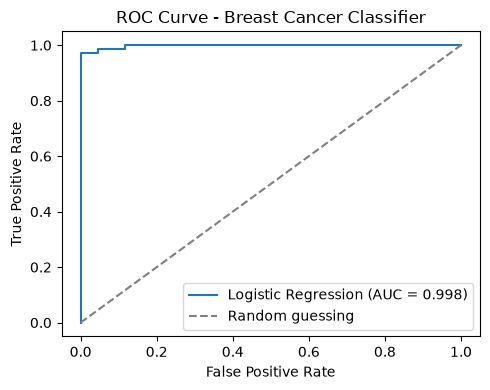

In [16]:
auc = roc_auc_score(y_test, probabilities)
print("AUC-ROC:", round(auc, 4))

fpr, tpr, thresholds = roc_curve(y_test, probabilities)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Breast Cancer Classifier")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation:
- AUC-ROC = **0.9977**, a number very close to 1.0 (the ideal model). This means the model can differentiate between malignant and benign cases excellently across all possible threshold values, not just at threshold = 0.5.

- The curve itself is very close to the upper left corner, far from the random guessing (diagonal) line, which confirms that the model has learned a real relationship between features and diagnosis, not just luck.

## Summary:
- **The model performed well** (F1 = 0.94-0.97, AUC = 0.9977) on data it hadn't seen during training.

- **The most important lesson from this exercise:** relying solely on accuracy would have blinded me to the three False Negatives, which are the most dangerous in a clinical setting.

> **Note: Every cell of above is explaied by markdown cell or by comments.**